<a href="https://colab.research.google.com/github/alekseimaksmv/Structure-and-neural-dynamics-in-partially-recurrent-neural-networks-pRNNs-/blob/main/3-neuron%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
# Imports
#%load_ext autoreload
#%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import colors
import itertools
import os

# For Google Colab
if not os.path.exists('src.py'):
  !git clone https://github.com/ghoshm/pRNN_tutorials.git
  %cd pRNN_tutorials

from src import create_pRNN_adj_matrix, plot_pRNN_architecture, plot_pRNN_dynamics

plt.style.use("./style_sheet.mplstyle")

eps = 1e-12

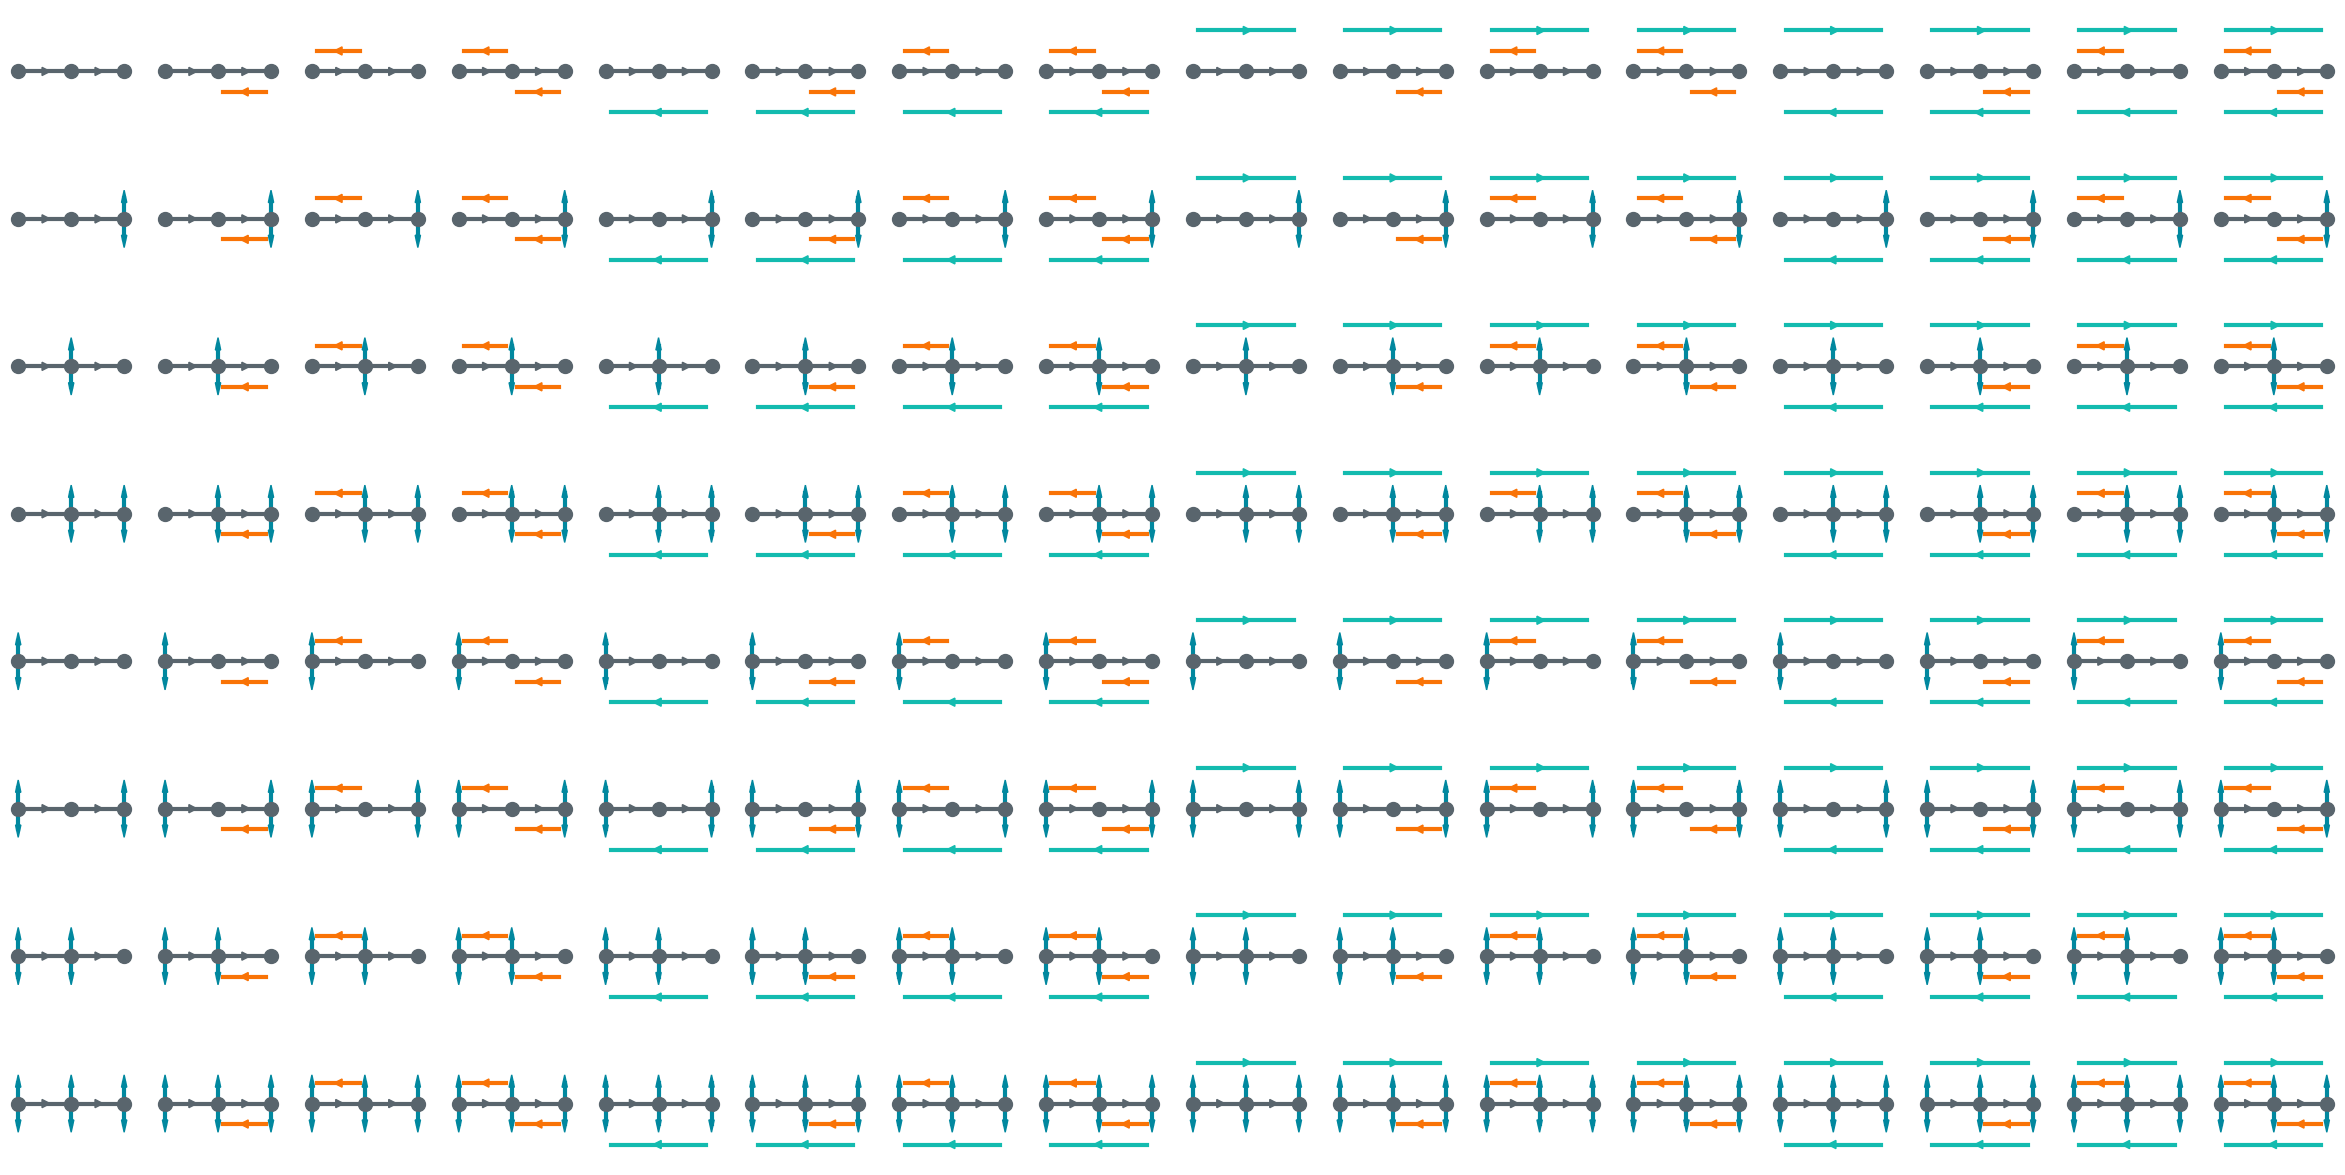

In [ ]:
# Define all pRNN structures

wm_flags = np.array(list(itertools.product([0,1], repeat=7)), dtype=int) # array: (architectures, extra connection pathways)

adj_ms = [create_pRNN_adj_matrix(wm_flag=f) for f in wm_flags] # list: architectures (source, target).

# Plot
fig, ax = plt.subplots(nrows=8, ncols=16, figsize=(30,15), sharex=True, sharey=True)
for a, _ in enumerate(ax.ravel()):
    plt.sca(ax.ravel()[a])
    plot_pRNN_architecture(wm_flags[a], ax=ax.ravel()[a])

In [ ]:
def simulate_pRNN_dynamics(adj_ms, x0, T):
    """
    Simulate dynamics from an initial state.
    Arguments:
        adj_ms: list of weight matrices (source, target).
        x0: an initial network state, array: (nodes).
        T: the number of steps to simulate for, int.
    Returns:
        x_hist: an array of dynamics, (architectures, time, nodes).
    """
    x_hist = np.zeros((len(adj_ms), T + 1, len(x0)), dtype=float) # array: (architectures, time, nodes)

    for a, W in enumerate(adj_ms):
        x = x0.copy() # current state
        x_hist[a, 0] = x # store

        for t in range(T):
            x = x @ W # update current state
            x_hist[a, t + 1] = x # store

    return x_hist

x0 = np.array([1.0, 0.0, 0.0]) # initial state to simulate from (input, hidden, output)
T = 15 # number of time steps to simulate

x_hist = simulate_pRNN_dynamics(adj_ms, x0, T)

In [ ]:
print(adj_ms[0])

[[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 0.]]


In [ ]:
# Figure
plot_pRNN_dynamics(x_hist=x_hist)

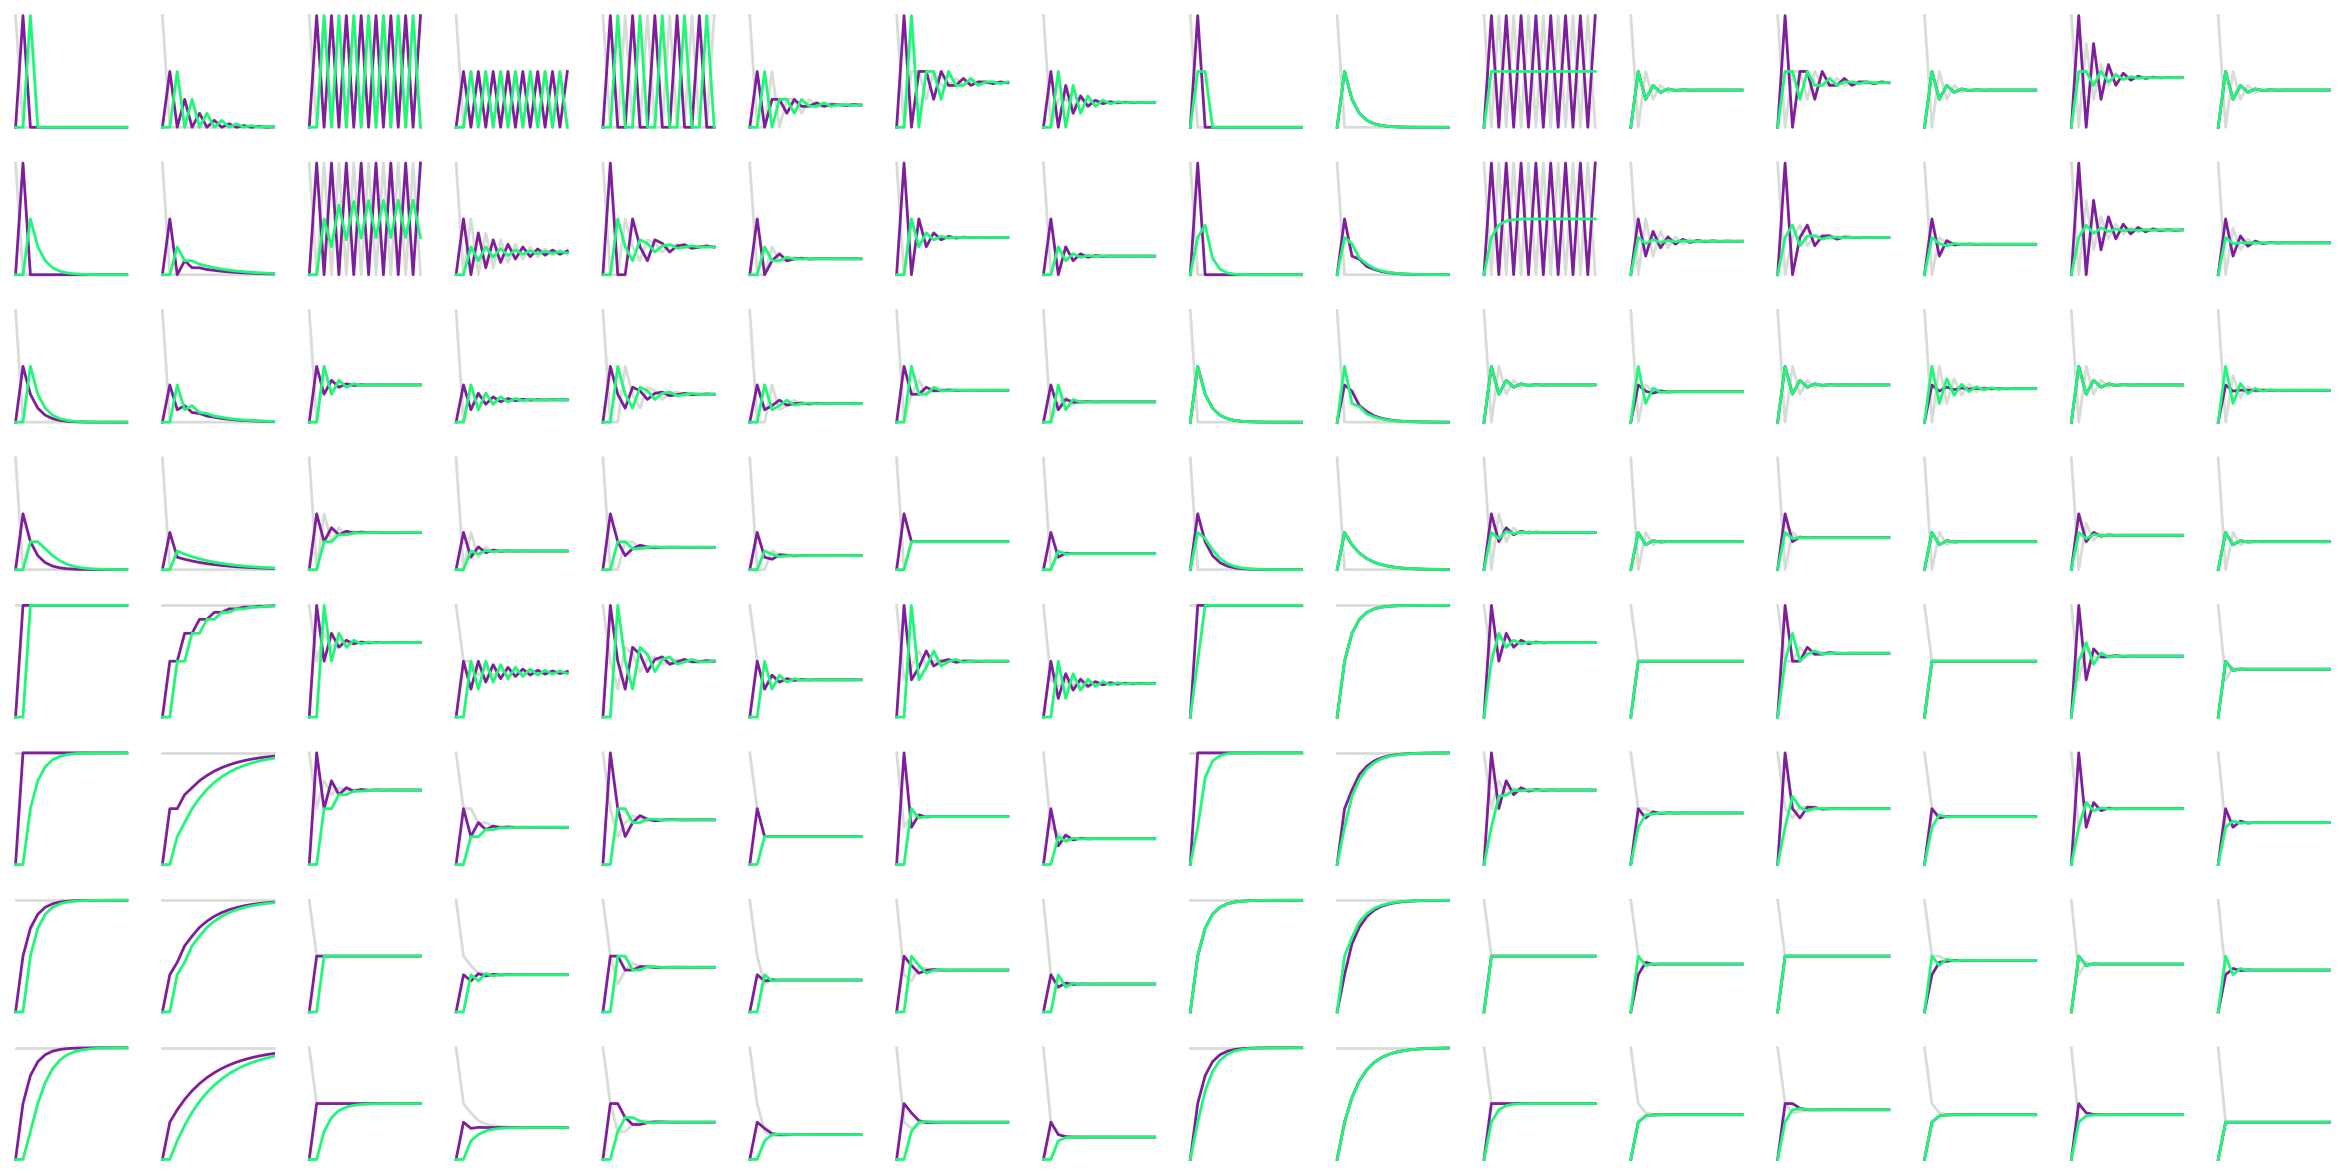

In [ ]:
# Normalise
for a, W in enumerate(adj_ms):
  adj_ms[a] = W / (np.sum(W, axis=0) + eps)
  #  for j in range(W.shape[1]):
  #     col_sum = W[:, j].sum()
  #     if col_sum >0:
  #       adj_ms[a][:,j] = W[:, j] / col_sum

# Simulate
x_hist = simulate_pRNN_dynamics(adj_ms, x0, T)

# Figure
plot_pRNN_dynamics(x_hist=x_hist)

If you have done this correctly, you will now see very different dynamics across the different models!

> 5. In the cell below use calculate the number of structures with unique dynamics (from  ```x_hist```).

In [ ]:
unique_a = np.unique(x_hist, axis=0)
len(unique_a) # no. of unique architectures
x_hist.shape

(128, 16, 3)

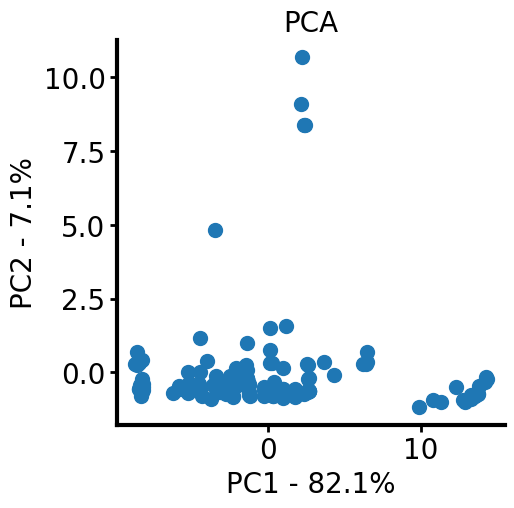

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#reshape data from 128,16,3 -> 128,48
pca_data = x_hist.reshape(128, -1)

#standardise
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

#PCA
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(scaled_data)

#calculate variation percentage for principle components
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals = 1)

#scatter plot
plt.scatter(pca_data[:, 0], pca_data[:, 1])
plt.title("PCA")
plt.xlabel("PC1 - {0}%".format(per_var[0]))
plt.ylabel("PC2 - {0}%".format(per_var[1]))
plt.show()

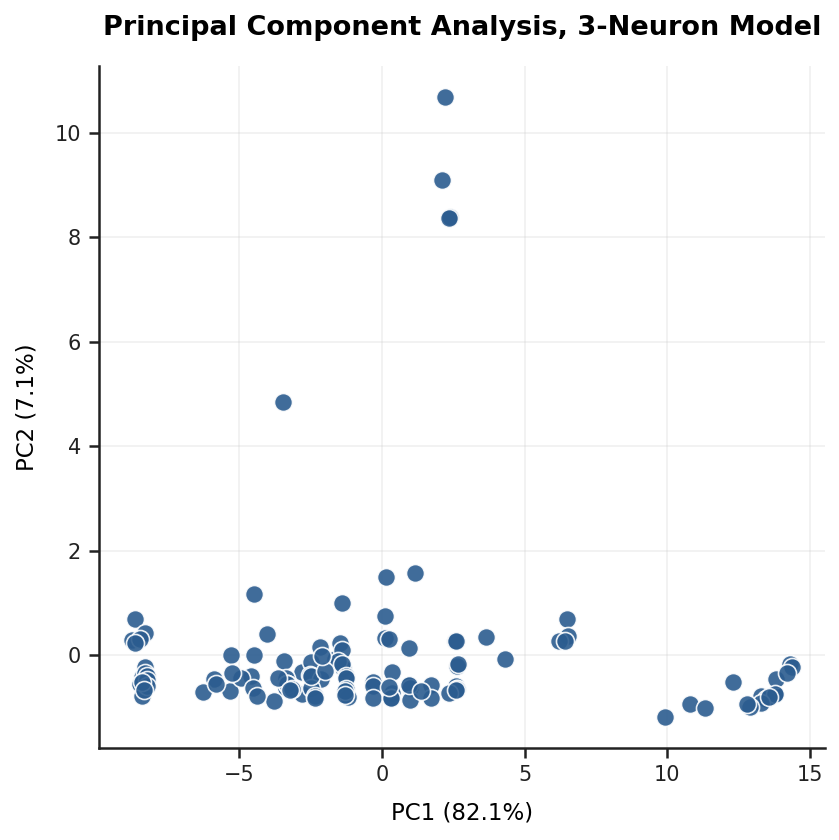

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

# --- Plotting the Data ---
# We use a professional slate blue, slightly larger markers,
# and a thin white edge to help overlapping points stand out.
ax.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    color='#2b5c8f',      # Professional slate blue
    s=75,                 # Slightly larger, clear markers
    edgecolors='#ffffff', # White border for overlapping points
    linewidth=0.8,
    alpha=0.9
)

# --- Titles and Labels ---
# Focus labels on clean, standard notation
ax.set_title("Principal Component Analysis, 3-Neuron Model", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel(f"PC1 ({per_var[0]}%)", fontsize=11, labelpad=8)
ax.set_ylabel(f"PC2 ({per_var[1]}%)", fontsize=11, labelpad=8)

# --- Spines & Grid ---
# Despine (remove top and right borders) for a clean modern aesthetic
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Make the remaining axes lines slightly thicker and darker
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_color('#222222')
ax.spines['bottom'].set_color('#222222')

# Add subtle, light gray gridlines only behind the data points
ax.grid(True, alpha=0.3, color='#cccccc', zorder=0)
ax.set_axisbelow(True) # Ensures grid lines sit behind the scatter points

# --- Adjust Ticks ---
ax.tick_params(colors='#222222', labelsize=10, width=1.2)

plt.tight_layout()
plt.show()

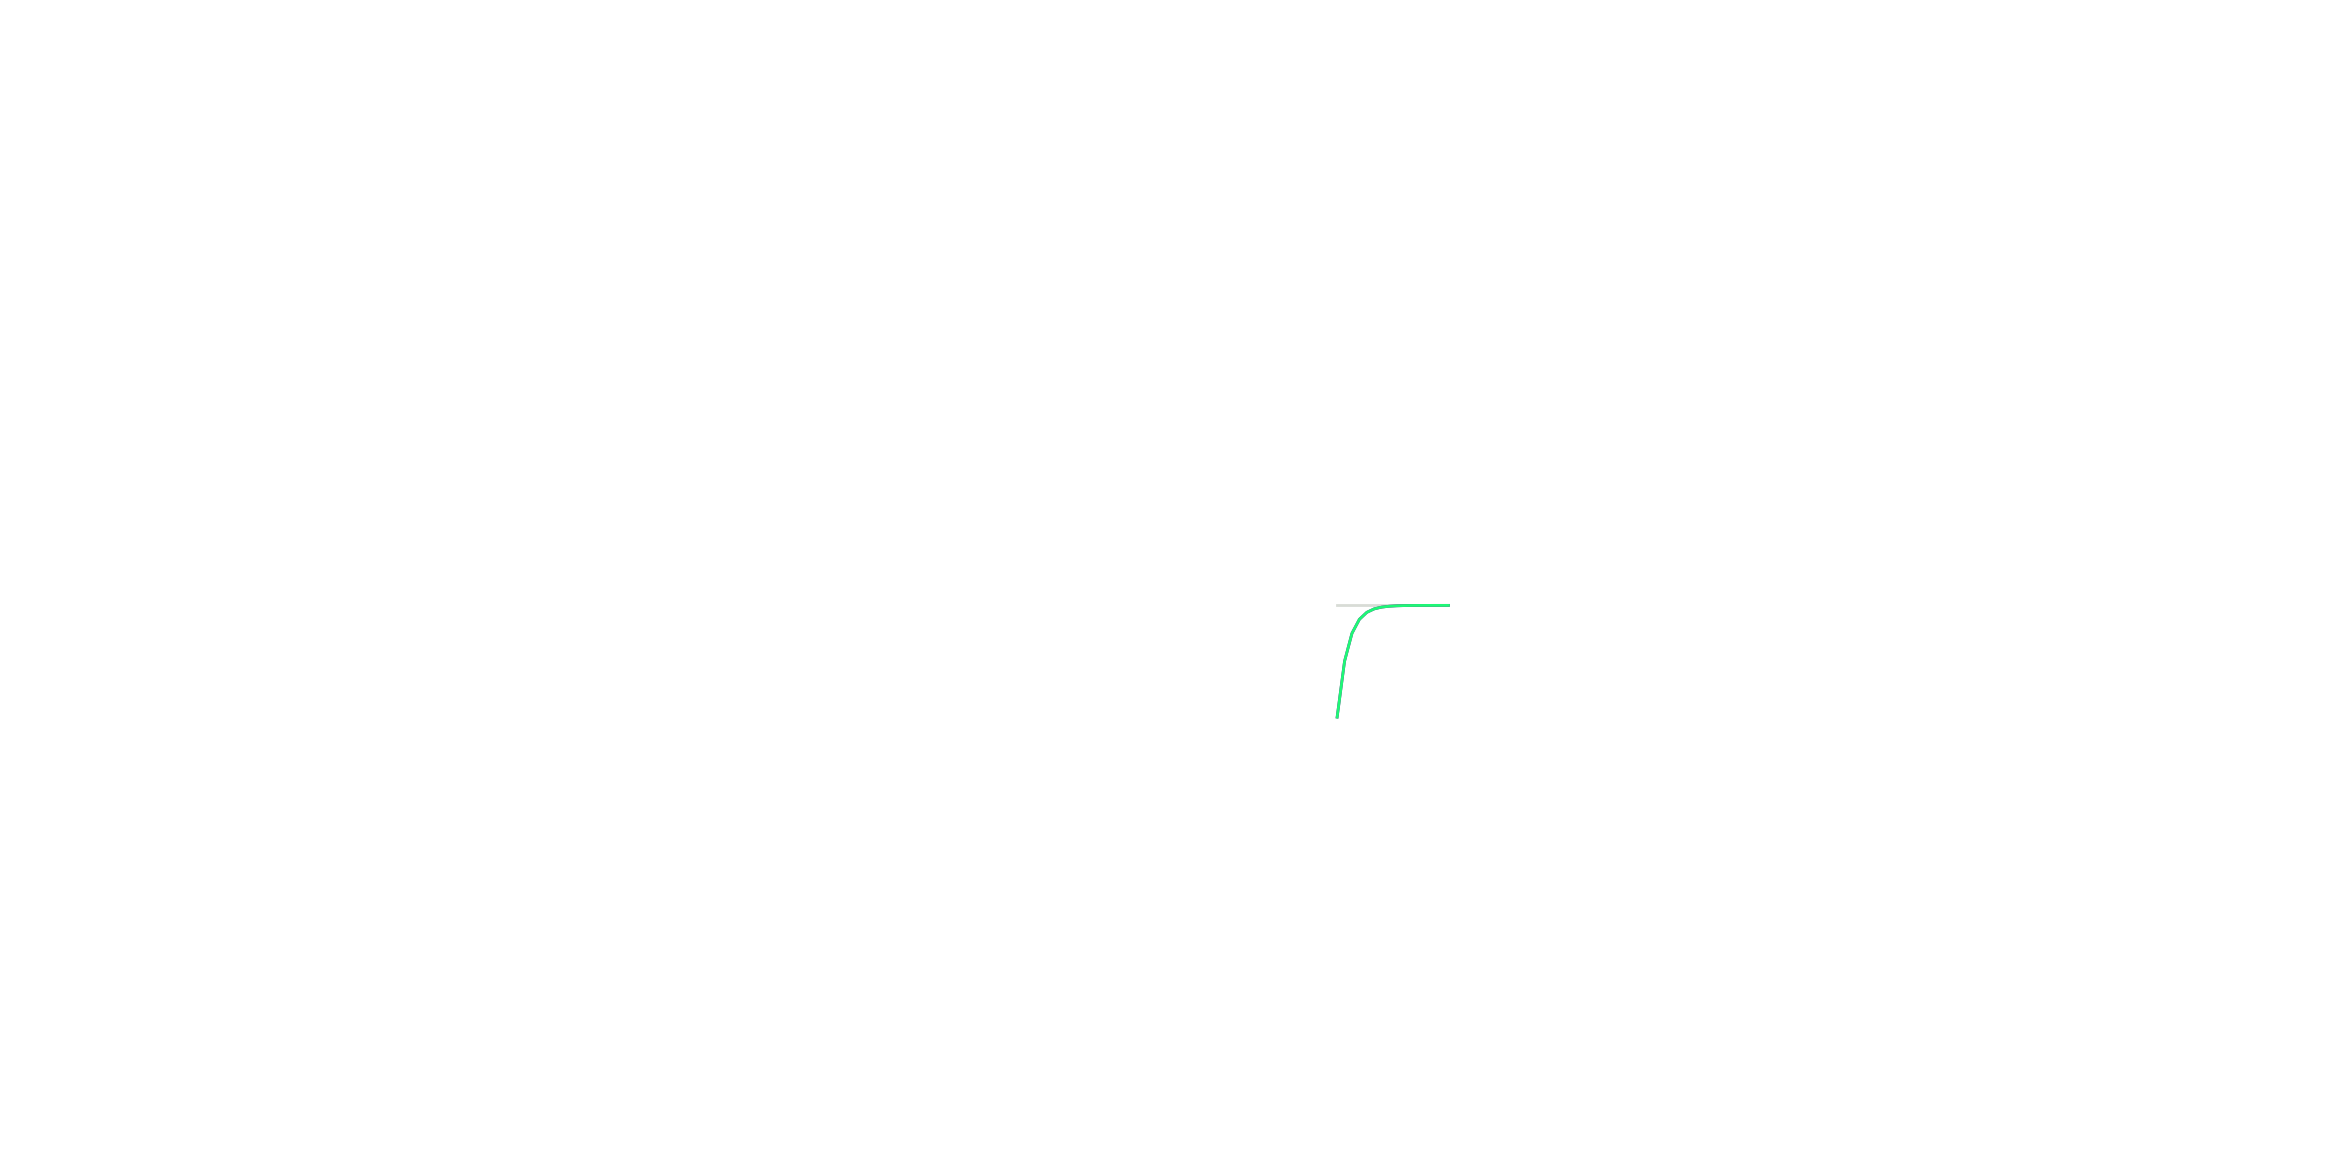

In [ ]:
# 1. Pick the architecture ID you want to isolate (e.g., 42)
arch_id = 73

# 2. Make a copy of your full data so we don't destroy your original variables
temp_x_hist = x_hist.copy()

# 3. Wipe out the data for all other 127 architectures, setting them to NaN (Not a Number)
# This keeps the array shape at (128, 16, 3) but makes the other 127 graphs completely invisible
for a in range(128):
    if a != arch_id:
        temp_x_hist[a, :, :] = np.nan

# 4. Feed it into your original function
plot_pRNN_dynamics(x_hist=temp_x_hist)

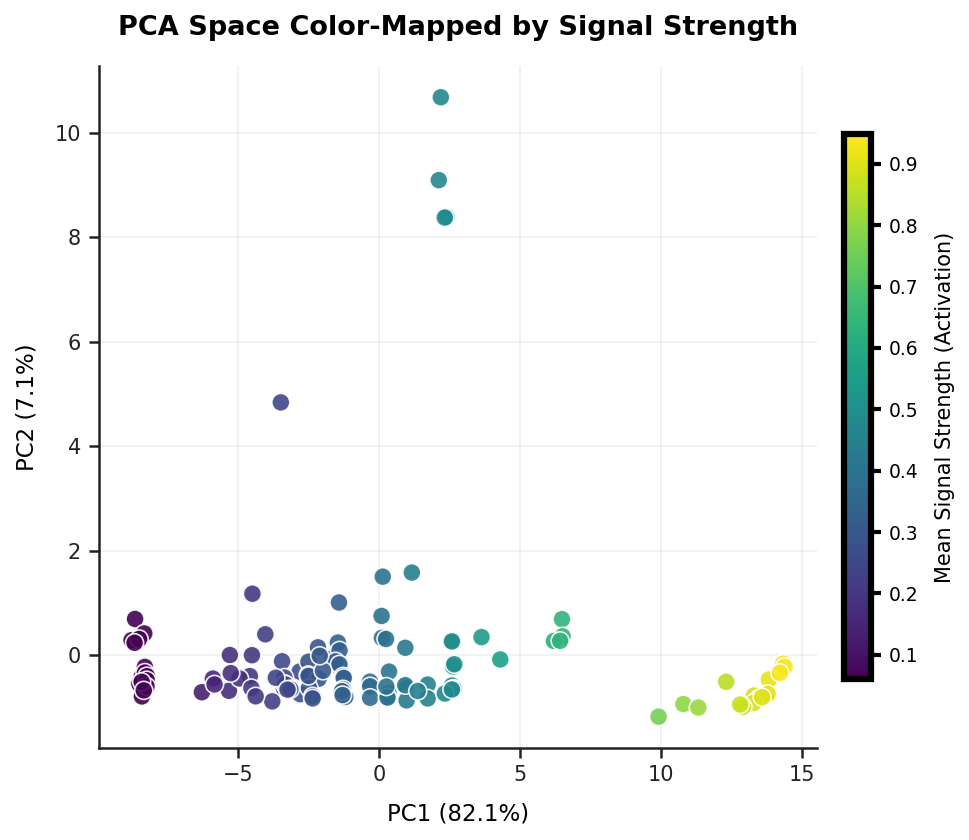

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- 1. Process Data & Run PCA ---
# Reshape data from (128, 16, 3) -> (128, 48)
pca_data_flat = x_hist.reshape(128, -1)

# Standardise
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data_flat)

# PCA
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(scaled_data)
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)

# --- 2. Calculate Signal Strength (The Gradient Vector) ---
# We take the mean absolute activation across all time steps and all 3 neurons.
# This gives us a single value per network representing total energy/persistence.
signal_strength = np.mean(np.abs(x_hist), axis=(1, 2))

# --- 3. Professional Academic Plotting ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

fig, ax = plt.subplots(figsize=(7, 6), dpi=150) # Made slightly wider to fit colorbar nicely

# Scatter plot using 'c' for the gradient mapping and 'viridis' (or 'plasma'/'inferno')
sc = ax.scatter(
    pca_coords[:, 0],
    pca_coords[:, 1],
    c=signal_strength,     # Color mapped to signal strength vector
    cmap='viridis',        # Professional, perceptually uniform colormap
    s=75,
    edgecolors='#ffffff',
    linewidth=0.8,
    alpha=0.9,
    zorder=3
)

# Add the colorbar custom-styled for academic papers
cbar = fig.colorbar(sc, ax=ax, pad=0.03, shrink=0.8)
cbar.set_label("Mean Signal Strength (Activation)", fontsize=10, labelpad=8)
cbar.ax.tick_params(labelsize=9)
cbar.solids.set_edgecolor("face") # Prevents faint white lines in some rendering engines

# --- Titles and Labels ---
ax.set_title("PCA Space Color-Mapped by Signal Strength", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel(f"PC1 ({per_var[0]}%)", fontsize=11, labelpad=8)
ax.set_ylabel(f"PC2 ({per_var[1]}%)", fontsize=11, labelpad=8)

# --- Spines & Grid ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_color('#222222')
ax.spines['bottom'].set_color('#222222')

ax.grid(True, alpha=0.3, color='#cccccc', zorder=0)
ax.set_axisbelow(True)

# --- Adjust Ticks ---
ax.tick_params(colors='#222222', labelsize=10, width=1.2)

plt.tight_layout()
plt.show()

In [ ]:
pca_data.shape

(128, 2)

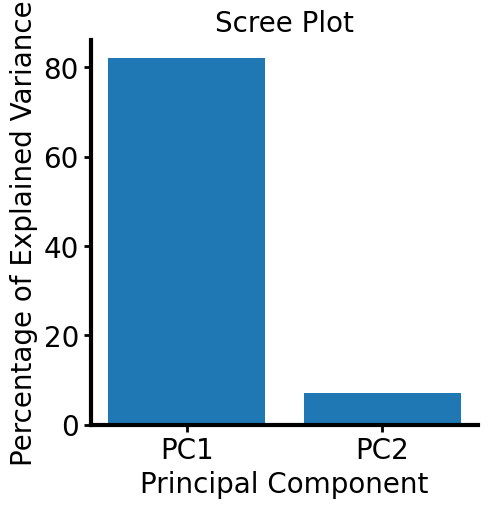

In [ ]:
#scree plot
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

plt.bar(x=range(1,len(per_var)+1), height=per_var, tick_label=labels)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.show()

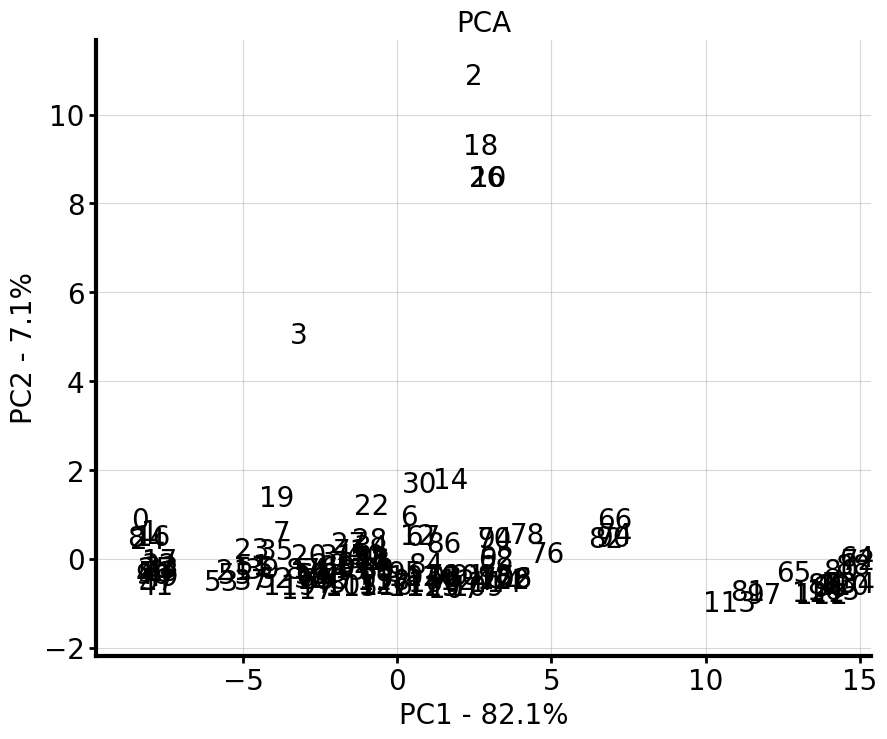

In [ ]:
#figure
plt.figure(figsize=(10, 8))

#loop through every architecture and plot its number at PCA coordinates
for i in range(len(pca_data)):
    plt.text(pca_data[i, 0],
             pca_data[i, 1],
             str(i),          #architecture index
             )

#scale graph
plt.xlim(pca_data[:, 0].min() - 1, pca_data[:, 0].max() + 1)
plt.ylim(pca_data[:, 1].min() - 1, pca_data[:, 1].max() + 1)

#plot
plt.title("PCA")
plt.xlabel("PC1 - {0}%".format(per_var[0]))
plt.ylabel("PC2 - {0}%".format(per_var[1]))
plt.grid(True, alpha=0.5) #grid for readability
plt.show()

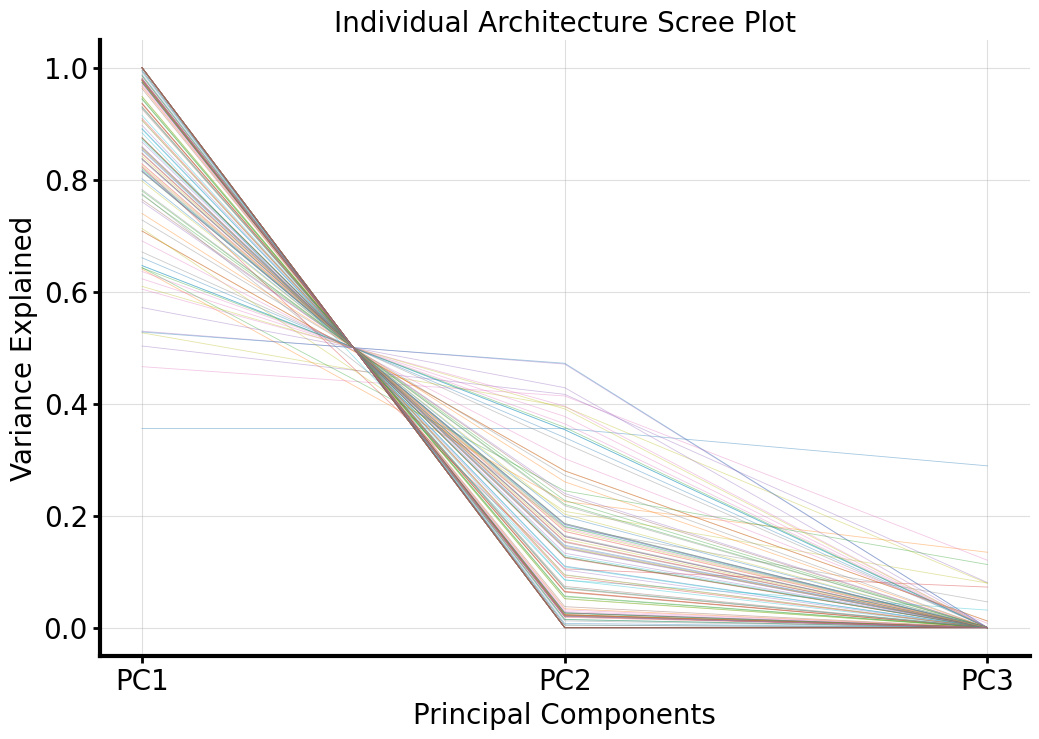

In [ ]:
#set storage
num_archs = x_hist.shape[0]
variance_ratios = np.zeros((num_archs,3))

#loop
for i in range(num_archs):
    arch_data = x_hist[i]
    pca = PCA(n_components=3, whiten=True)
    pca.fit(arch_data)

    #store 'explained_variance_ratio_'. gives the % variance by each PC
    variance_ratios[i] = pca.explained_variance_ratio_

#plot
plt.figure(figsize=(12, 8))

pc_labels = ['PC1','PC2','PC3']
pc_indices = [1,2,3]

#points
for i in range(num_archs):
    plt.plot(pc_indices, variance_ratios[i], alpha=0.4, linewidth=0.6)

#plt.plot(pc_indices, variance_ratios[3], color='red', linewidth=3)

#plot settings
plt.xticks(pc_indices, pc_labels)
plt.ylabel('Variance Explained')
plt.xlabel('Principal Components')
plt.title('Individual Architecture Scree Plot')
plt.grid(True, alpha=0.4)
plt.show()

/tmp/ipykernel_1298/117499485.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


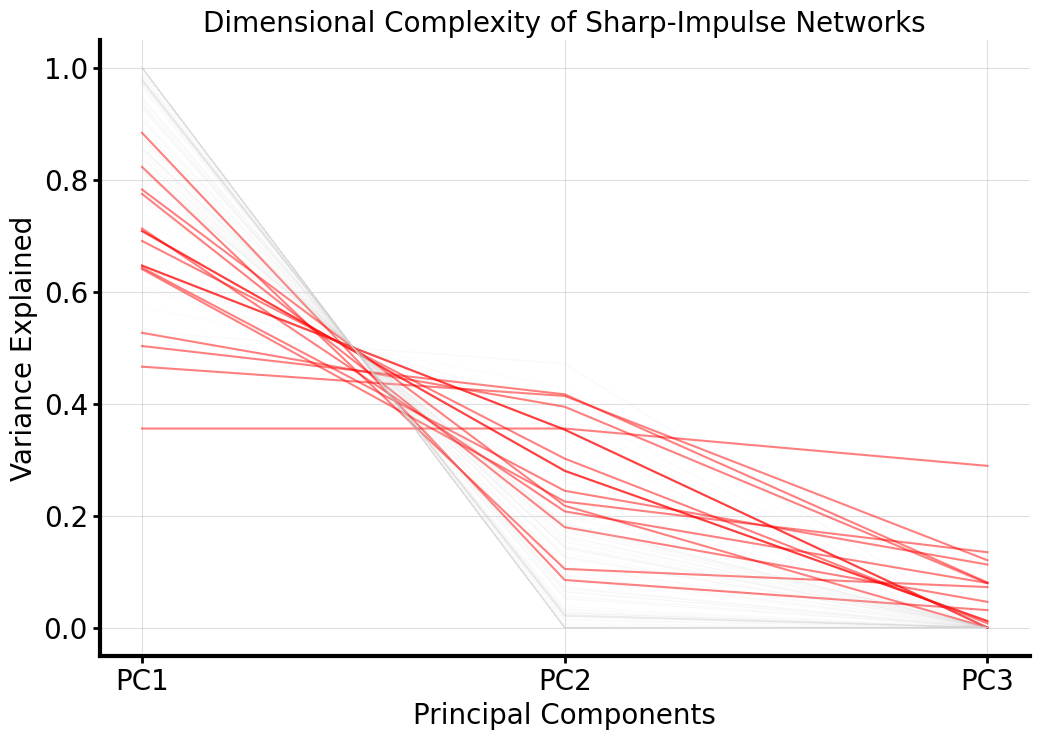

In [ ]:
#highlight specific group
group = [0,1,8,9,16,17,24,25,32,33,40,41,48,49,56,57]

plt.figure(figsize=(12, 8))
pc_indices = [1,2,3]

#loop
for i in range(num_archs):
    if i in group:
        plt.plot(pc_indices, variance_ratios[i],
                 color='red', alpha=0.5, linewidth=1.5)
    else:
        plt.plot(pc_indices, variance_ratios[i],
                 color='lightgray', alpha=0.1, linewidth=0.5)

#plot
plt.xticks(pc_indices, ['PC1','PC2','PC3'])
plt.ylabel('Variance Explained')
plt.xlabel('Principal Components')
plt.title('Dimensional Complexity of Sharp-Impulse Networks')
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

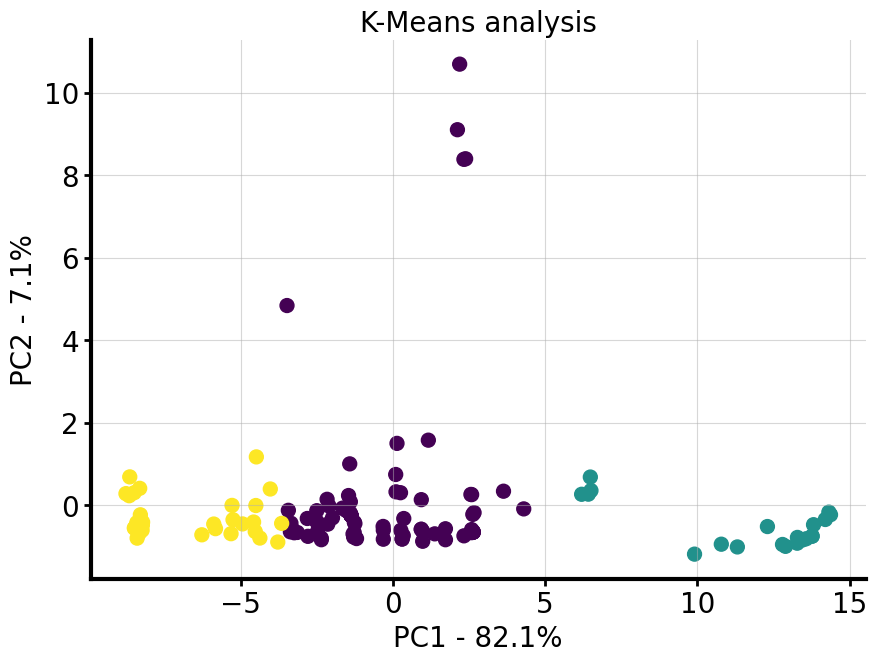

In [ ]:
from sklearn.cluster import KMeans

#fit model
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(pca_data)

#plot original pca data
plt.figure(figsize=(10, 7))

#use coordinates from pca but colours from kmeans
scatter = plt.scatter(pca_data[:, 0], pca_data[:, 1],
                     c=cluster_labels,
                     cmap='viridis',
                     )

#plot
plt.title(f"K-Means analysis")
plt.xlabel(f"PC1 - {per_var[0]}%")
plt.ylabel(f"PC2 - {per_var[1]}%")

plt.grid(True, alpha=0.5)
plt.show()

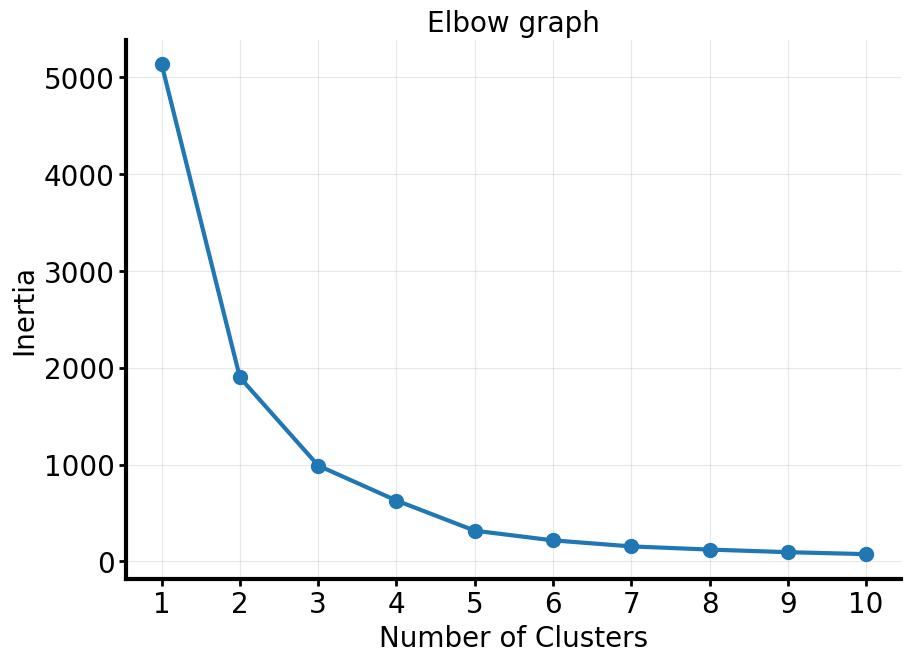

In [ ]:
#calculate inertia
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_data)
    inertia_values.append(km.inertia_)

#plot
plt.figure(figsize=(10, 7))
plt.plot(k_range, inertia_values, marker='o')

plt.title('Elbow graph')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
pip install kneed

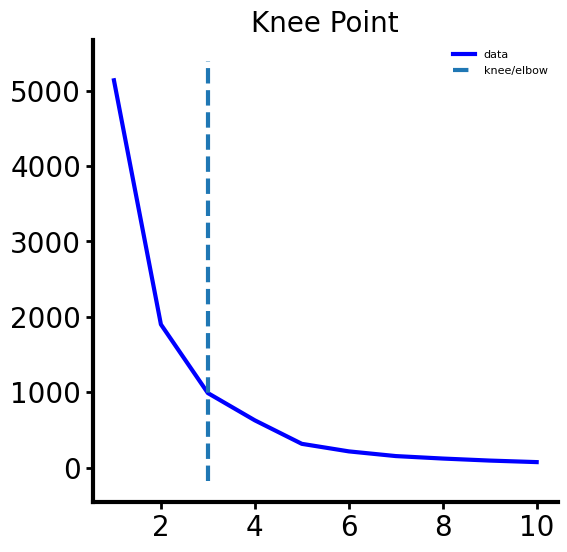

In [ ]:
from kneed import KneeLocator

#locate elbow
kl = KneeLocator(range(1, 11), inertia_values, curve="convex", direction="decreasing")

kl.plot_knee()

In [ ]:
#2d pca
kmeans_2d = KMeans(n_clusters=3, random_state=42)
labels_pca = kmeans_2d.fit_predict(pca_data)

#48d pca
kmeans_48d = KMeans(n_clusters=3, random_state=42)
labels_scaled = kmeans_48d.fit_predict(scaled_data)

#comparison
from sklearn.metrics import adjusted_rand_score

#adjusted rand index
ari_score = adjusted_rand_score(labels_pca, labels_scaled)
matches = np.sum(labels_pca == labels_scaled)

#info
print(f"{matches} / 128")
print(f"{ari_score:.4f}")

119 / 128
0.7754


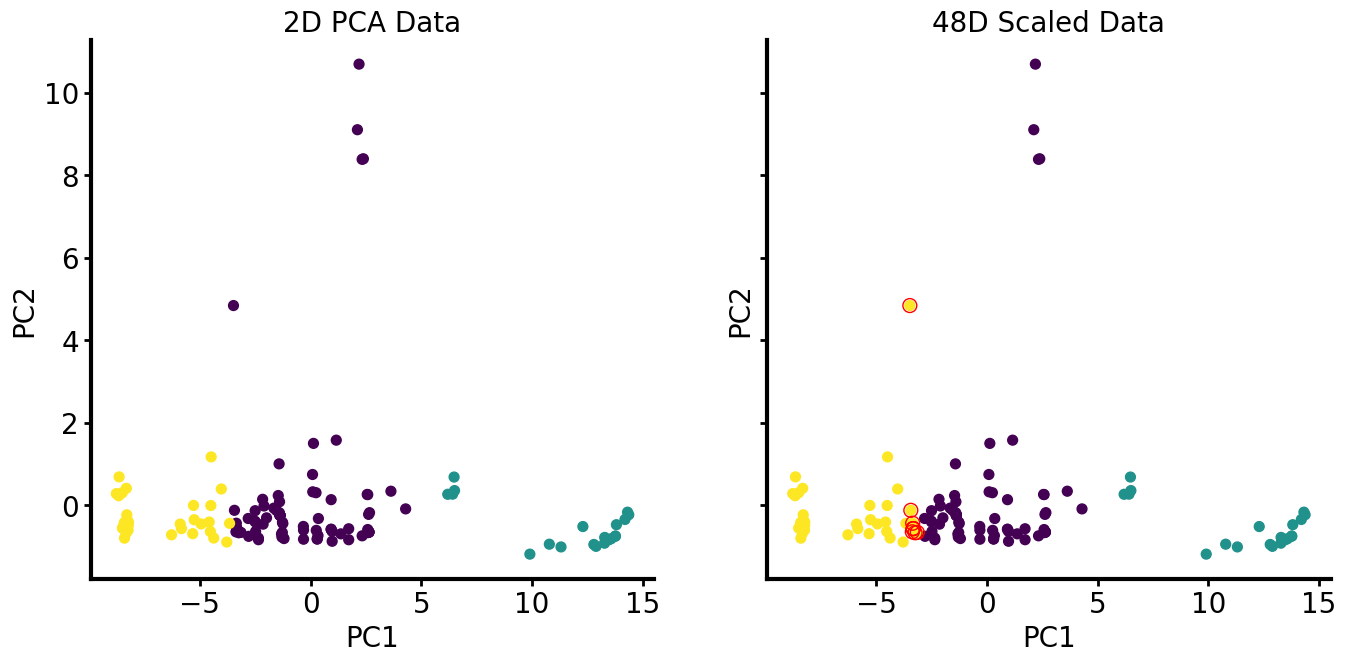

(array([  3,  20,  36,  54,  59,  61,  63,  85, 103]),)


In [ ]:
#plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

#2d data plot
ax1.scatter(pca_data[:, 0], pca_data[:, 1], c=labels_pca, s=50)
ax1.set_title(f"2D PCA Data")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")

#48d data plot
ax2.scatter(pca_data[:, 0], pca_data[:, 1], c=labels_scaled, s=50)
ax2.set_title(f"48D Scaled Data")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")

#group the clusters
clusters = np.unique(labels_scaled)

#finding differences
difs = np.where(labels_pca != labels_scaled)
ax2.scatter(pca_data[difs, 0], pca_data[difs, 1],
            facecolors='none', edgecolors='red', s=100, linewidth=1)
plt.show()
print(difs)

In [ ]:
idx = np.argsort(np.sum(abs(pca_data), axis=1)) # something like this

[127 115 125 123 114 122  98 108 106  77  75 101 124  93 107  99  91 109
 126 118 111  95  83 116 110  79 102 100  60  29  43  69  62  92  86  38
  50  47  31  58  76  84  94  71  34  13  44  42  11  15  46  78  45  27
  67  28  70  22  68  12  30  14   6   4  26  10  18   2 113  81  97  65
 121  89 105 112  96 120  73 104  80  88  64  72  82  90  74  66 119 117
  85 103  49  55  53  87  54  57  33  48  59  61  63  25  41  56  52  39
  17  51  32   9  40  21  37  23  24  35  16   8  36   1   0   7   5  20
  19   3]


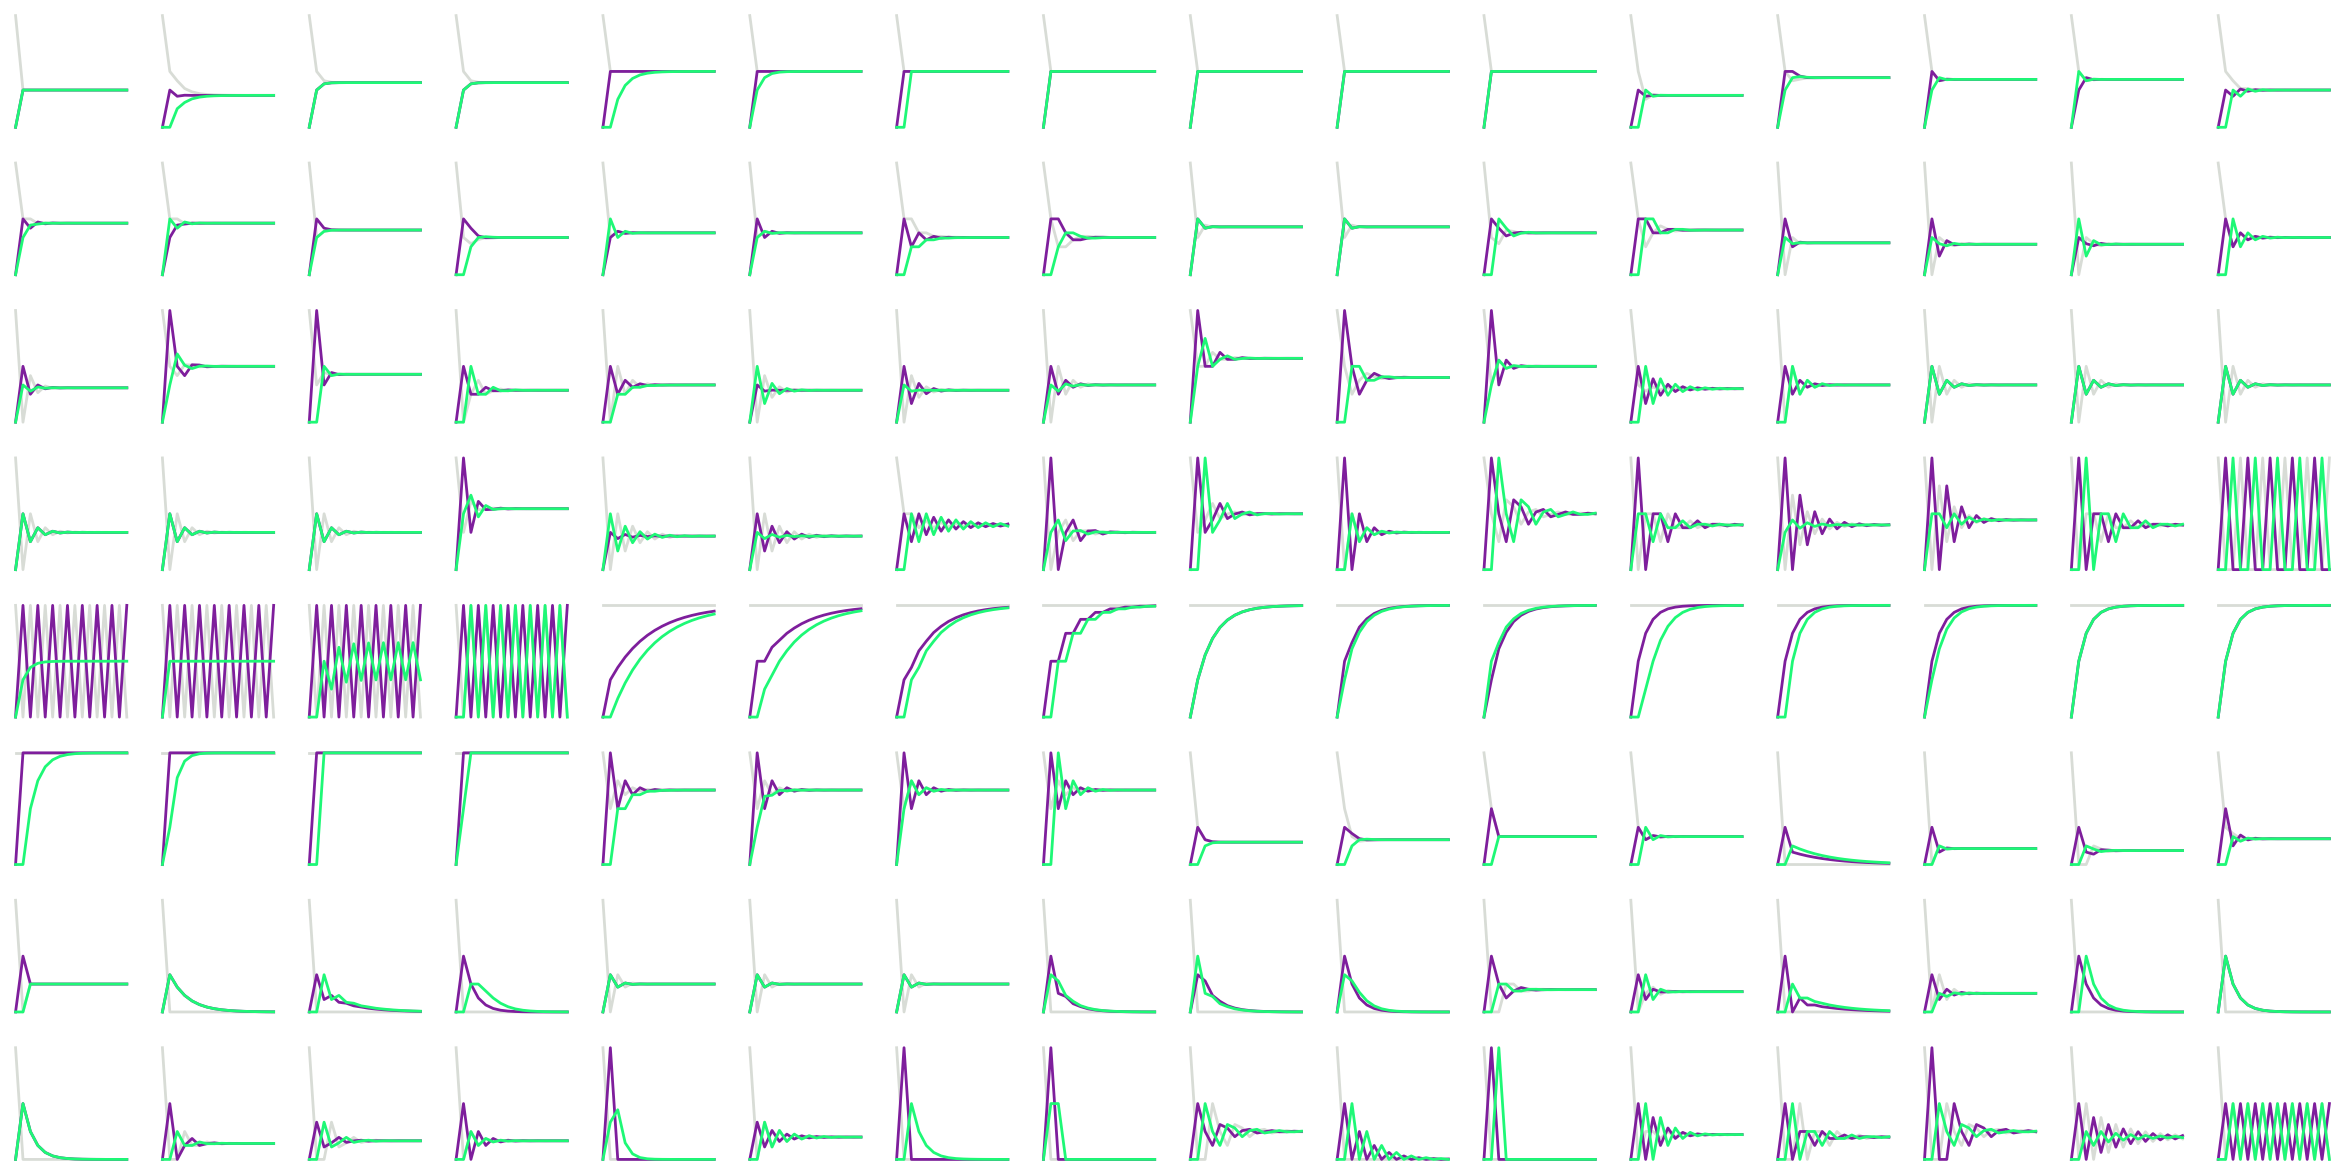

In [ ]:
all_clusters_sorted = np.full((128, x_hist.shape[1], x_hist.shape[2]), np.nan)

current_row = 0

all_refined_ids = []

#loop through clusters
for target_cluster in [0, 1, 2]:

    #isolate data
    idx = np.where(labels_scaled == target_cluster)[0]
    cluster_dynamics = x_hist[idx]
    if len(cluster_dynamics) == 0:
        continue

    #calculate variance for each cluster
    scores = []
    for i in range(len(cluster_dynamics)):
        variance = np.sum(np.abs(np.diff(cluster_dynamics[i], axis=0)))
        scores.append(variance)

    #sorting
    sub_sort_idx = np.argsort(scores)
    cluster_dynamics_sorted = cluster_dynamics[sub_sort_idx]
    refined_ids = idx[sub_sort_idx]

    #save id
    all_refined_ids.extend(refined_ids)

    #plot
    num_architectures = len(cluster_dynamics_sorted)
    all_clusters_sorted[current_row : current_row + num_architectures] = cluster_dynamics_sorted
    current_row += num_architectures
#plot
plot_pRNN_dynamics(x_hist=all_clusters_sorted)

#print order
print(np.array(all_refined_ids))

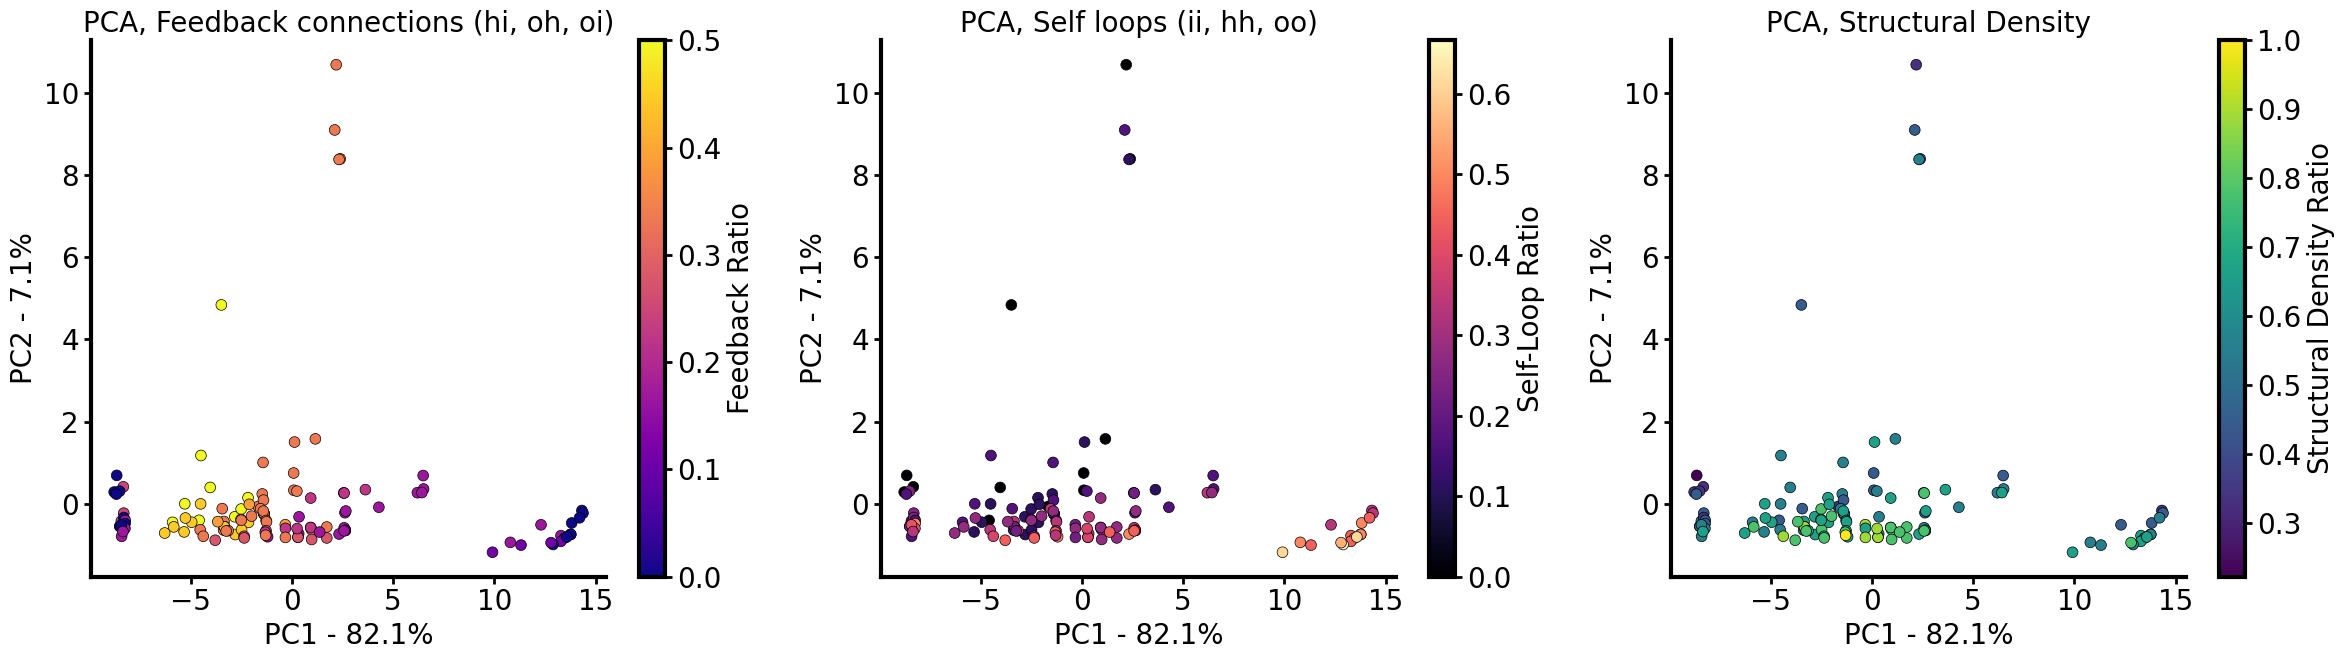

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

weight_matrices = np.array(adj_ms)

#set storage
densities = []
self_loop_scores = []
feedback_scores = []

#calculate structural density
for W in weight_matrices:
    non_zero_connections = np.sum(np.abs(W) > 0.01)
    density = non_zero_connections / 9.0
    densities.append(density)

#calculate self loops
    self_loops_sum = np.abs(W[0,0]) + np.abs(W[1,1]) + np.abs(W[2,2]) # ii, hh, oo
#feedback loops
    feedback_sum = np.abs(W[1,0]) + np.abs(W[2,1]) + np.abs(W[2,0]) # hi, oh, oi
#feedforward
    feedforward_sum = np.abs(W[0,1]) + np.abs(W[0,2]) + np.abs(W[1,2]) # i->h, h->o, i->o
    total_strength = self_loops_sum + feedback_sum + feedforward_sum

    if total_strength > 0:
        self_loop_metric = self_loops_sum / total_strength
        feedback_metric = feedback_sum / total_strength
    else:
        self_loop_metric = 0.0
        feedback_metric = 0.0

    self_loop_scores.append(self_loop_metric)
    feedback_scores.append(feedback_metric)

# Convert lists to arrays for plotting
self_loop_scores = np.array(self_loop_scores)
feedback_scores = np.array(feedback_scores)
densities = np.array(densities)

#plot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))

#feedback plot
scatter1 = ax1.scatter(pca_data[:, 0], pca_data[:, 1], c=feedback_scores, cmap='plasma',
                       edgecolors='black', s=60, linewidths=0.5)
fig.colorbar(scatter1, ax=ax1, label='Feedback Ratio')
ax1.set_title("PCA, Feedback connections (hi, oh, oi)")
ax1.set_xlabel("PC1 - {0}%".format(per_var[0]))
ax1.set_ylabel("PC2 - {0}%".format(per_var[1]))

#self loop plot
scatter2 = ax2.scatter(pca_data[:, 0], pca_data[:, 1], c=self_loop_scores, cmap='magma',
                       edgecolors='black', s=60, linewidths=0.5)
fig.colorbar(scatter2, ax=ax2, label='Self-Loop Ratio')
ax2.set_title("PCA, Self loops (ii, hh, oo)")
ax2.set_xlabel("PC1 - {0}%".format(per_var[0]))
ax2.set_ylabel("PC2 - {0}%".format(per_var[1]))

#structural density plot
scatter3 = ax3.scatter(pca_data[:, 0], pca_data[:, 1], c=densities, cmap='viridis',
                       edgecolors='black', s=60, linewidths=0.5)
fig.colorbar(scatter3, ax=ax3, label='Structural Density Ratio')
ax3.set_title("PCA, Structural Density")
ax3.set_xlabel("PC1 - {0}%".format(per_var[0]))
ax3.set_ylabel("PC2 - {0}%".format(per_var[1]))

plt.tight_layout()
plt.show()

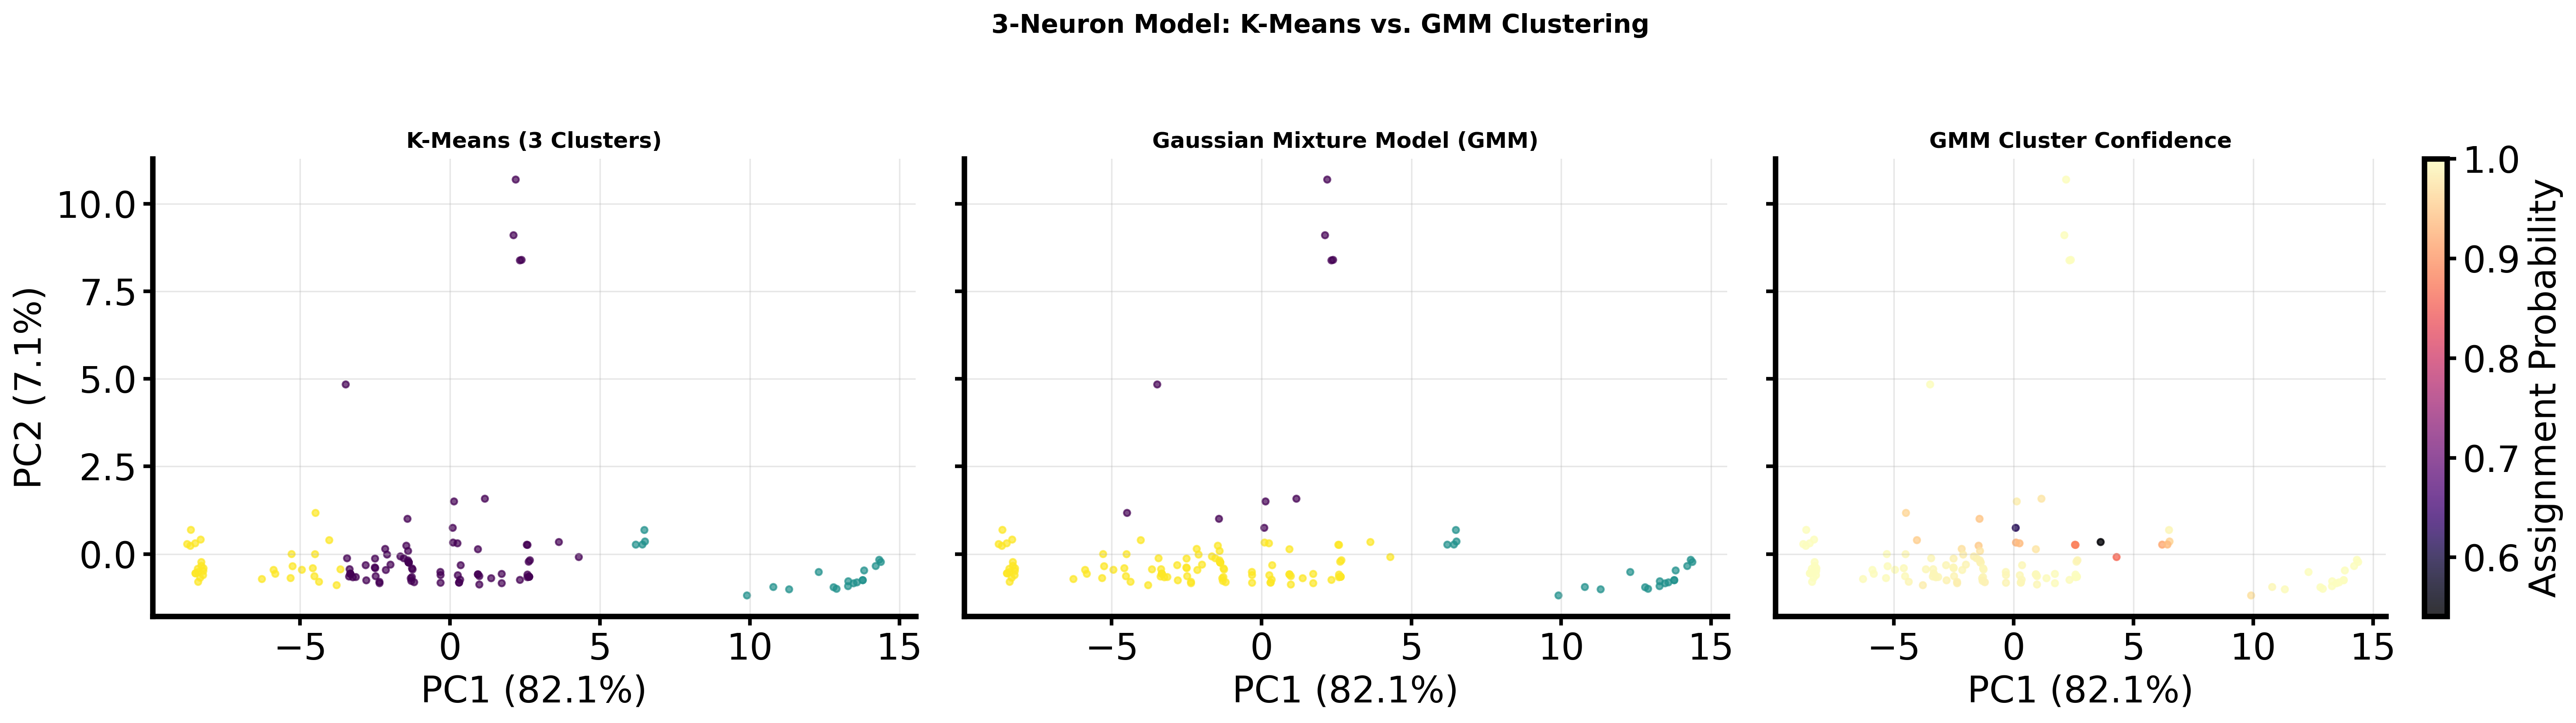

Exact label alignment between K-Means and GMM: 59 / 128 points


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

# 1. Fit Gaussian Mixture Model on 2D PCA Data
n_clusters = 3  # Adjust number of components as needed
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm_labels = gmm.fit_predict(pca_data)

# Extract max assignment probability per point for confidence visualization
gmm_probs = np.max(gmm.predict_proba(pca_data), axis=1)

# 2. Side-by-Side Visual Comparison: K-Means vs GMM vs GMM Confidence
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5.5), sharex=True, sharey=True, dpi=300)

# Panel 1: Original K-Means
ax1.scatter(pca_data[:, 0], pca_data[:, 1], c=cluster_labels, cmap='viridis', s=12, alpha=0.7)
ax1.set_title("K-Means (3 Clusters)", fontsize=12, fontweight='bold')
ax1.set_xlabel(f"PC1 ({per_var[0]}%)")
ax1.set_ylabel(f"PC2 ({per_var[1]}%)")
ax1.grid(True, alpha=0.3)

# Panel 2: Gaussian Mixture Model (GMM)
ax2.scatter(pca_data[:, 0], pca_data[:, 1], c=gmm_labels, cmap='viridis', s=12, alpha=0.7)
ax2.set_title("Gaussian Mixture Model (GMM)", fontsize=12, fontweight='bold')
ax2.set_xlabel(f"PC1 ({per_var[0]}%)")
ax2.grid(True, alpha=0.3)

# Panel 3: GMM Assignment Confidence / Uncertainty
sc = ax3.scatter(pca_data[:, 0], pca_data[:, 1], c=gmm_probs, cmap='magma', s=12, alpha=0.8)
fig.colorbar(sc, ax=ax3, label='Assignment Probability')
ax3.set_title("GMM Cluster Confidence", fontsize=12, fontweight='bold')
ax3.set_xlabel(f"PC1 ({per_var[0]}%)")
ax3.grid(True, alpha=0.3)

plt.suptitle("3-Neuron Model: K-Means vs. GMM Clustering", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print overlap metric
agreed = np.sum(cluster_labels == gmm_labels)
print(f"Exact label alignment between K-Means and GMM: {agreed} / {len(pca_data)} points")

BIC-optimal k: 6
AIC-optimal k: 9


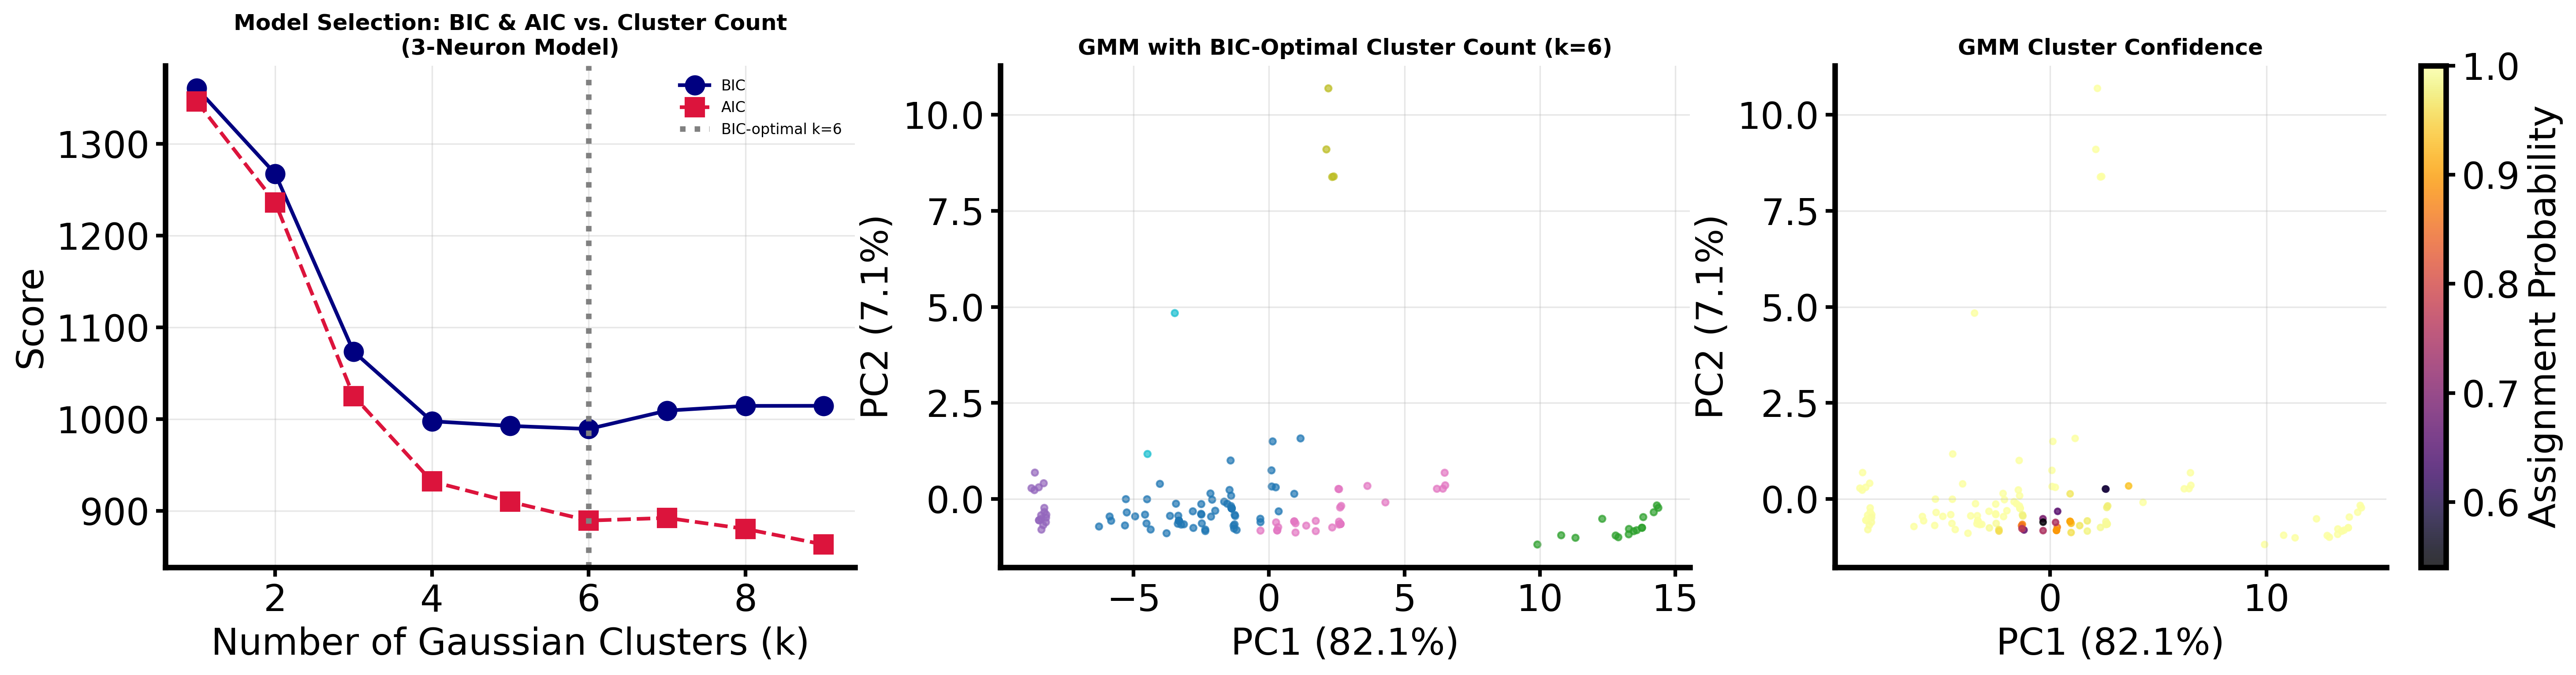

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# 1. Sweep GMM Components using BIC & AIC (3-neuron model)
# Note: with only 128 architectures, don't sweep too high — components
# beyond ~10 will likely be overfitting noise given the small sample size.
n_range = range(1, 10)
bic_scores = []
aic_scores = []

for k in n_range:
    gmm = GaussianMixture(n_components=k, random_state=42).fit(pca_data)
    bic_scores.append(gmm.bic(pca_data))
    aic_scores.append(gmm.aic(pca_data))

bic_scores = np.array(bic_scores)
aic_scores = np.array(aic_scores)

# find the actual minimum (not assumed — read off the data)
optimal_k_bic = list(n_range)[np.argmin(bic_scores)]
optimal_k_aic = list(n_range)[np.argmin(aic_scores)]

print(f"BIC-optimal k: {optimal_k_bic}")
print(f"AIC-optimal k: {optimal_k_aic}")

# Use BIC's choice as your selected k (standard convention: BIC penalises
# complexity more heavily than AIC, so it's generally preferred to avoid overfitting)
optimal_k = optimal_k_bic

# 2. Fit the BIC-optimal GMM
gmm_opt = GaussianMixture(n_components=optimal_k, random_state=42)
labels_opt = gmm_opt.fit_predict(pca_data)
probs_opt = gmm_opt.predict_proba(pca_data)
confidence = np.max(probs_opt, axis=1)  # assignment probability for the winning cluster

# 3. Plot Information Criteria & Optimal Cluster Map
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5.5), dpi=300)

# Panel A: BIC/AIC curve
ax1.plot(n_range, bic_scores, marker='o', label='BIC', color='navy', linewidth=2)
ax1.plot(n_range, aic_scores, marker='s', label='AIC', color='crimson', linestyle='--', linewidth=2)
ax1.axvline(x=optimal_k, color='gray', linestyle=':', label=f'BIC-optimal k={optimal_k}')
ax1.set_title("Model Selection: BIC & AIC vs. Cluster Count\n(3-Neuron Model)",
              fontsize=12, fontweight='bold')
ax1.set_xlabel("Number of Gaussian Clusters (k)")
ax1.set_ylabel("Score")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Panel B: Optimal GMM clusters
scatter_b = ax2.scatter(pca_data[:, 0], pca_data[:, 1], c=labels_opt, cmap='tab10', s=12, alpha=0.7)
ax2.set_title(f"GMM with BIC-Optimal Cluster Count (k={optimal_k})", fontsize=12, fontweight='bold')
ax2.set_xlabel(f"PC1 ({per_var[0]}%)")
ax2.set_ylabel(f"PC2 ({per_var[1]}%)")
ax2.grid(True, alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Panel C: Assignment confidence
scatter_c = ax3.scatter(pca_data[:, 0], pca_data[:, 1], c=confidence, cmap='inferno',
                         s=10, alpha=0.8, vmin=confidence.min(), vmax=1.0)
fig.colorbar(scatter_c, ax=ax3, label='Assignment Probability')
ax3.set_title("GMM Cluster Confidence", fontsize=12, fontweight='bold')
ax3.set_xlabel(f"PC1 ({per_var[0]}%)")
ax3.set_ylabel(f"PC2 ({per_var[1]}%)")
ax3.grid(True, alpha=0.3)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()